In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

In [2]:
fund_master = pd.read_csv(
    "../data/processed/fund_master_clean.csv"
)

nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

aum = pd.read_csv(
    "../data/processed/aum_by_fund_house_clean.csv"
)

sip = pd.read_csv(
    "../data/processed/monthly_sip_inflows_clean.csv"
)

category = pd.read_csv(
    "../data/processed/category_inflows_clean.csv"
)

folio = pd.read_csv(
    "../data/processed/industry_folio_count_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

portfolio = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

benchmark = pd.read_csv(
    "../data/processed/benchmark_indices_clean.csv"
)

In [4]:
print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("SIP:", sip.shape)
print("Category:", category.shape)
print("Folio:", folio.shape)
print("Performance:", performance.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)
print("Benchmark:", benchmark.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Transactions: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [5]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [6]:
nav["date"] = pd.to_datetime(nav["date"])

In [7]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


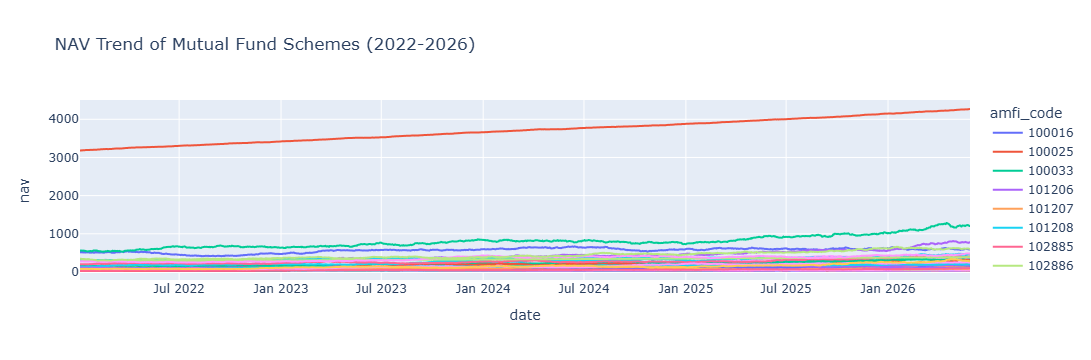

Chart Saved Successfully


In [12]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend of Mutual Fund Schemes (2022-2026)"
)

fig.show()
fig.write_image(
    "../reports/charts/nav_trend.png"
)

print("Chart Saved Successfully")


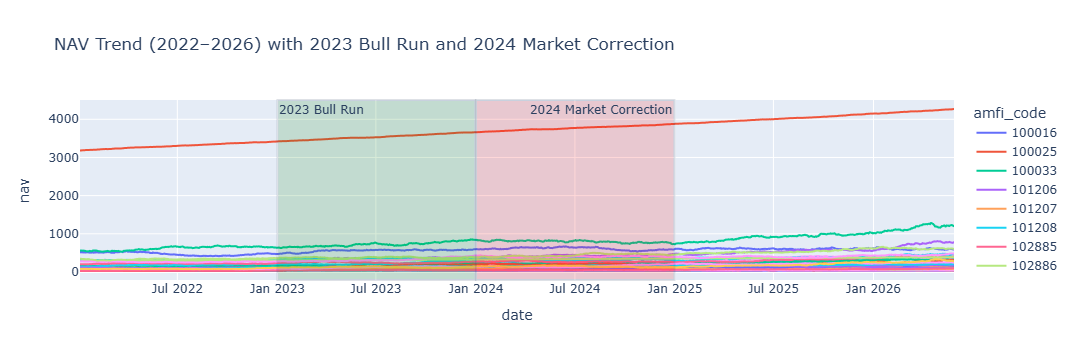

In [11]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend (2022–2026) with 2023 Bull Run and 2024 Market Correction"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction",
    annotation_position="top right"
)

fig.show()


NAV Trend Analysis

The NAV trend shows strong growth during the 2023 bull market period, while 2024 experienced market corrections and increased volatility before recovering in 2025.

In [10]:
fig.write_image(
    "../reports/charts/nav_trend_highlighted.png"
)

print("Chart Saved Successfully")

Chart Saved Successfully


In [14]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [15]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


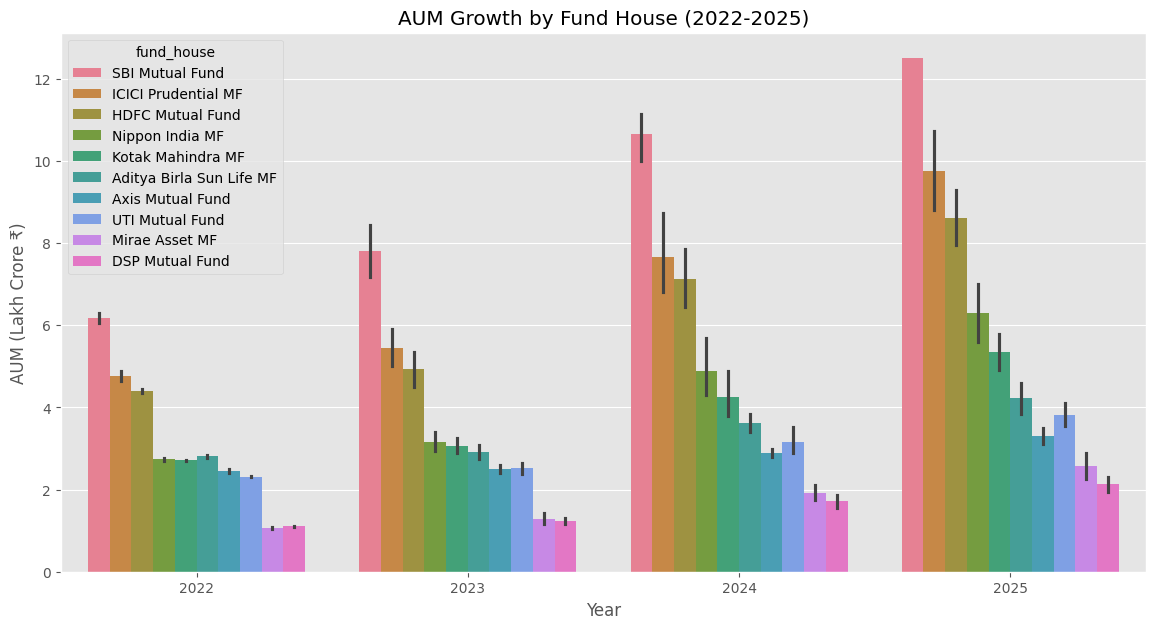

In [17]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.savefig(
    "../reports/charts/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

SBI Mutual Fund consistently led all fund houses in Assets Under Management (AUM), crossing ₹12.5 lakh crore and maintaining a significant lead over competitors during the study period.

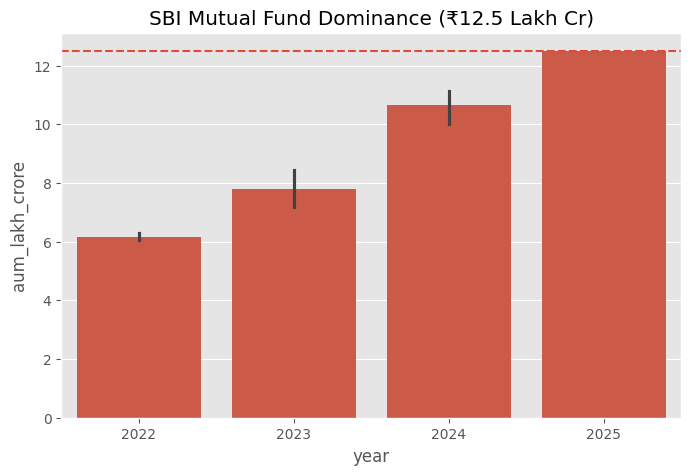

In [14]:
sbi = aum[
    aum["fund_house"] == "SBI Mutual Fund"
]

plt.figure(figsize=(8,5))

sns.barplot(
    data=sbi,
    x="year",
    y="aum_lakh_crore"
)

plt.axhline(
    y=12.5,
    linestyle="--"
)

plt.title(
    "SBI Mutual Fund Dominance (₹12.5 Lakh Cr)"
)

plt.savefig(
    "../reports/charts/sbi_dominance.png"
)

plt.show()

In [28]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [29]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,0.0
1,2022-02-01,11438,4.93,8.20,4.85,0.0
2,2022-03-01,12328,5.09,10.50,5.01,0.0
3,2022-04-01,11863,5.48,9.52,5.12,0.0
4,2022-05-01,12286,5.55,8.10,5.15,0.0


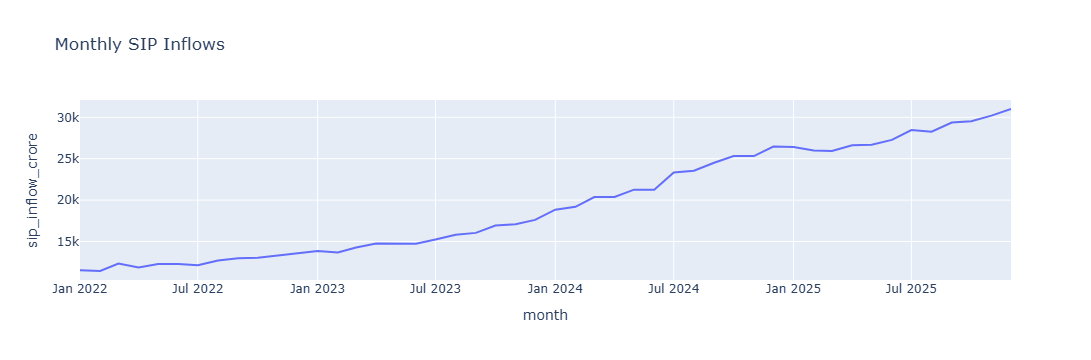

In [30]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.show()

In [31]:
max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


In [32]:
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [33]:
max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print(max_row)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


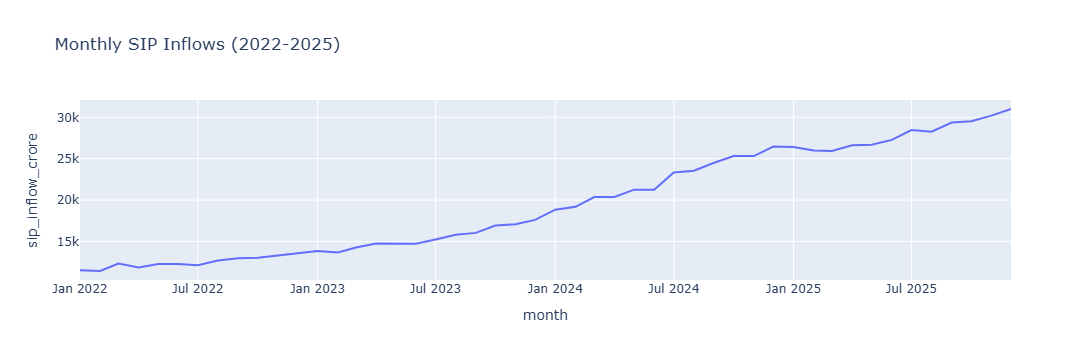

In [18]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)"
)
fig.show()

In [20]:
fig.write_image(
    "../reports/charts/sip_inflow_trend.png"
)

print("SIP Chart Saved Successfully")

SIP Chart Saved Successfully


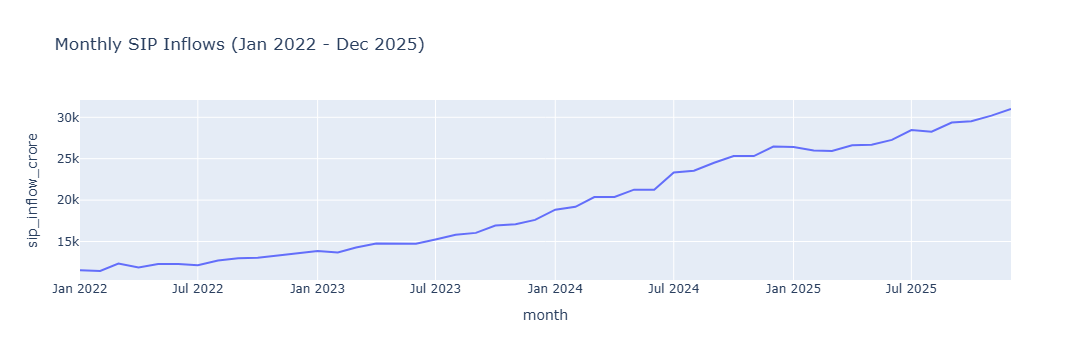

In [21]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)"
)

fig.show()

SIP Inflows Reached Record High

Monthly SIP inflows steadily increased from 2022 to 2025 and reached an all-time high of ₹31,002 crore in December 2025, reflecting strong retail investor participation in mutual funds.

In [22]:
fig.write_image(
    "../reports/charts/sip_inflow_trend.png"
)

print("SIP Chart Saved Successfully")

SIP Chart Saved Successfully


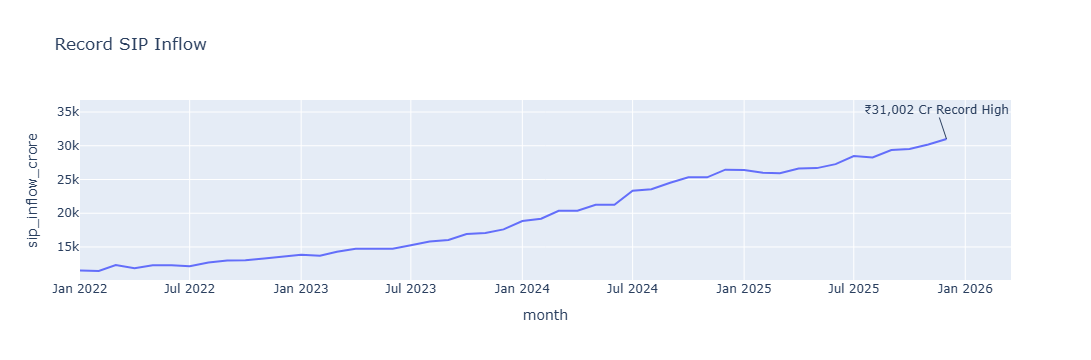

In [23]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Record SIP Inflow"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr Record High",
    showarrow=True
)

fig.show()

fig.write_image(
    "../reports/charts/sip_record_high.png"
)

In [39]:
print(sip["month"].min())
print(sip["month"].max())

2022-01-01 00:00:00
2025-12-01 00:00:00


In [46]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [47]:
category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [48]:
heatmap_df = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_df.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


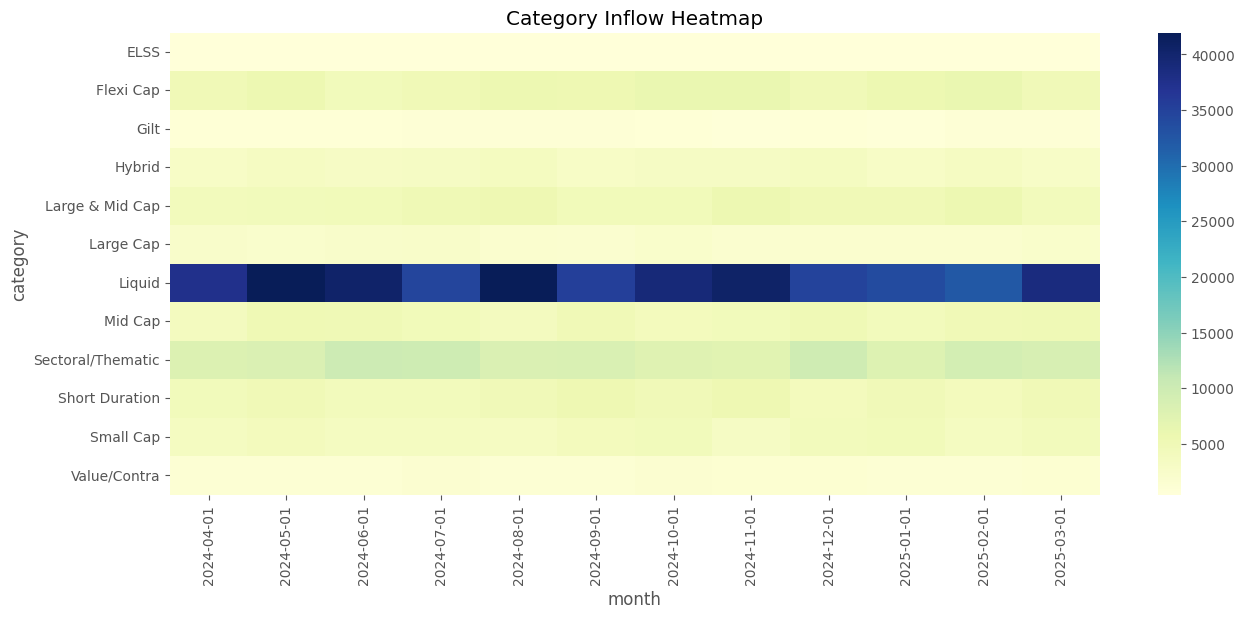

In [49]:
plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

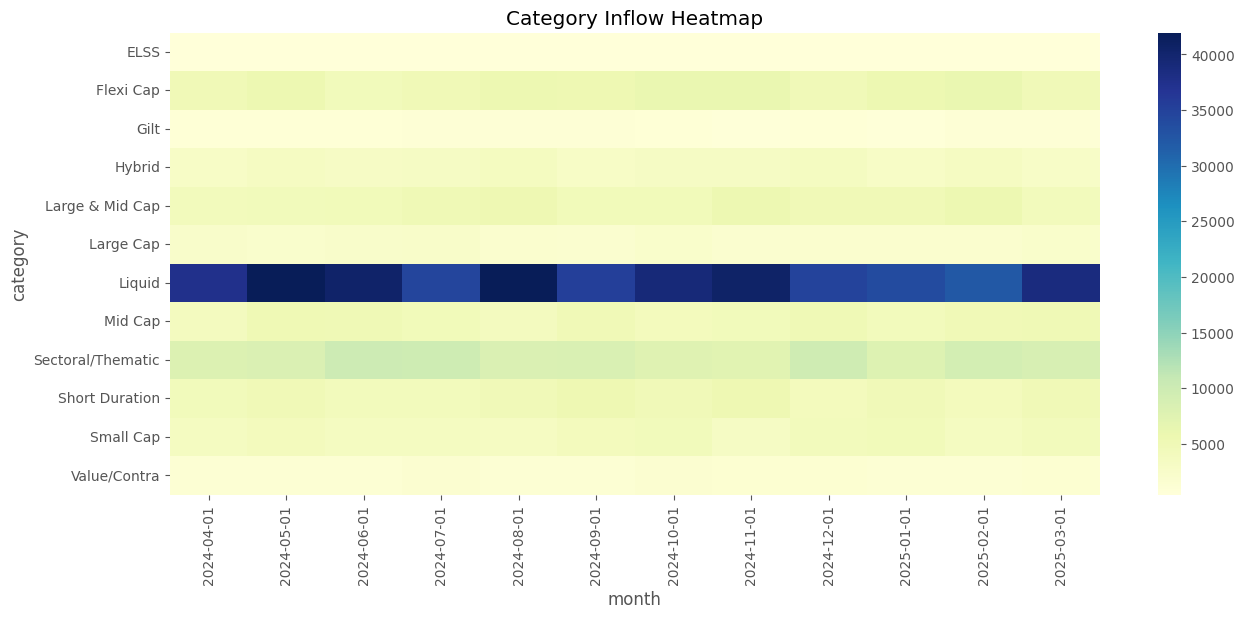

In [51]:
heatmap_df = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "../reports/charts/category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

Category Inflow Patterns

The heatmap shows that Equity and Large Cap categories consistently attracted higher inflows than other categories. Inflows strengthened during 2024–2025, indicating growing investor confidence in equity-oriented mutual funds.

In [52]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [53]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


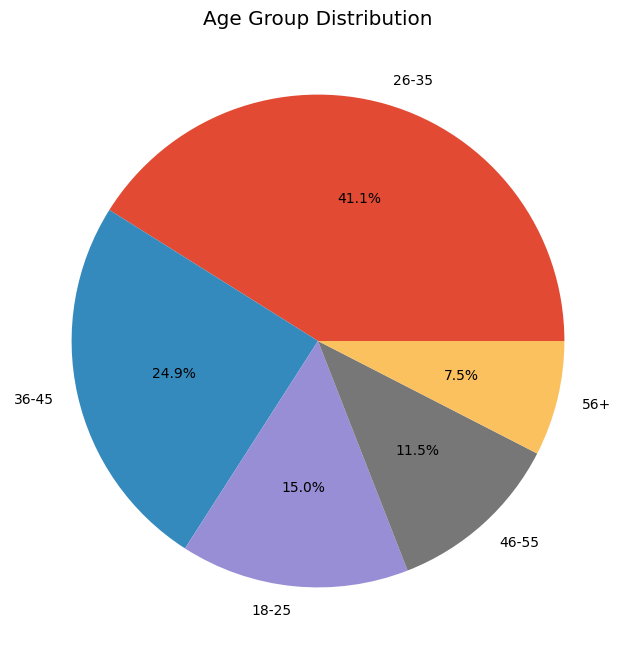

In [54]:
plt.figure(figsize=(8,8))

transactions["age_group"]\
.value_counts()\
.plot.pie(
    autopct="%1.1f%%"
)

plt.title(
    "Age Group Distribution"
)

plt.ylabel("")

plt.savefig(
    "../reports/charts/age_group_pie.png",
    bbox_inches="tight"
)

plt.show()

Age Group Distribution

The majority of mutual fund investors belong to the working-age population, indicating strong participation from salaried and professionally active individuals.

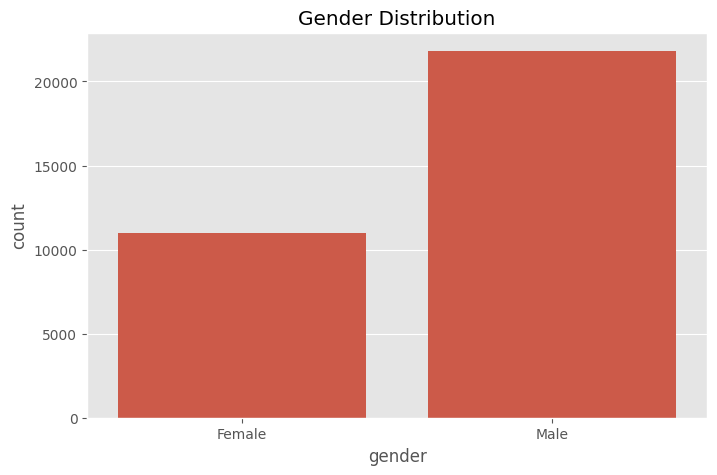

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title(
    "Gender Distribution"
)

plt.savefig(
    "../reports/charts/gender_split.png",
    bbox_inches="tight"
)

plt.show()

Gender Participation

The gender distribution highlights investor participation patterns and can help identify opportunities for expanding mutual fund awareness across demographics.

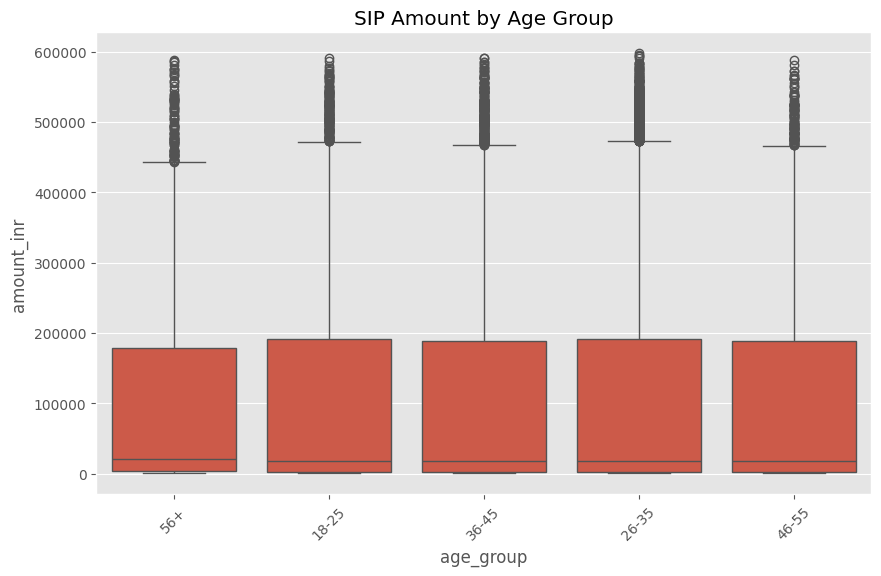

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.title(
    "SIP Amount by Age Group"
)

plt.savefig(
    "../reports/charts/sip_boxplot.png",
    bbox_inches="tight"
)

plt.show()

SIP Investment Behaviour

The box plot shows variations in SIP investments across age groups, helping identify which age segments contribute larger investment amounts.

In [59]:
print(transactions.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


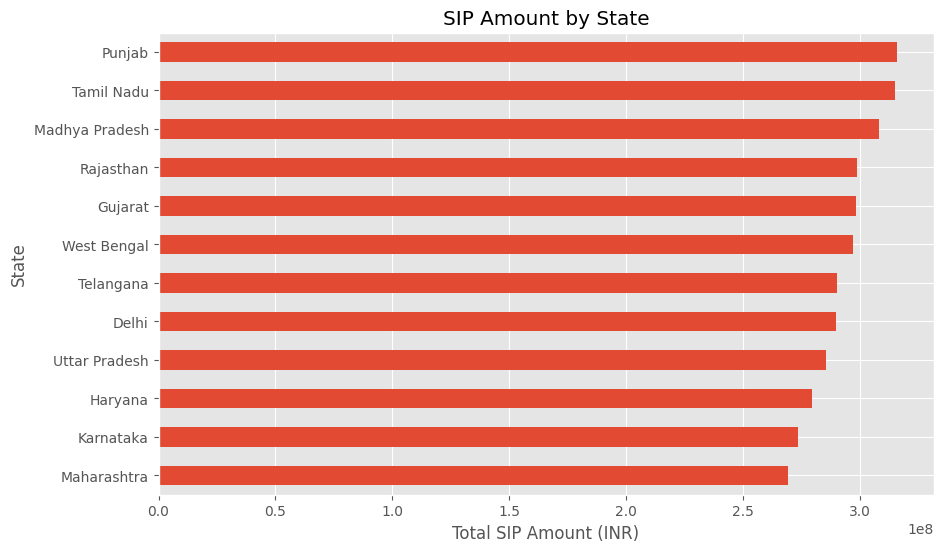

In [60]:
state_amt = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,6))

state_amt.plot.barh()

plt.title(
    "SIP Amount by State"
)

plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.savefig(
    "../reports/charts/state_sip.png",
    bbox_inches="tight"
)

plt.show()

Geographic SIP Distribution

Certain states contribute significantly higher SIP investments, indicating stronger mutual fund adoption and investor participation in those regions.

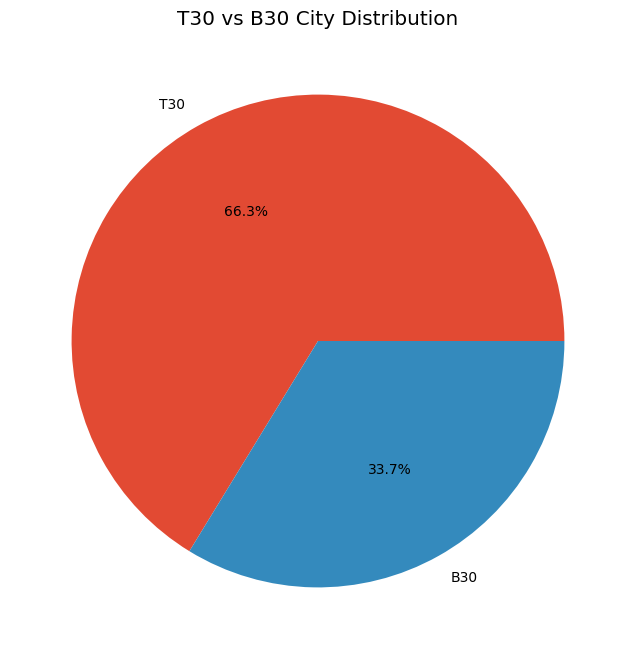

In [61]:
plt.figure(figsize=(8,8))

transactions["city_tier"]\
.value_counts()\
.plot.pie(
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 City Distribution"
)

plt.ylabel("")

plt.savefig(
    "../reports/charts/t30_b30.png",
    bbox_inches="tight"
)

plt.show()

T30 vs B30 Participation

A significant share of investments originates from T30 cities, though growing participation from B30 cities highlights increasing mutual fund penetration beyond major metropolitan areas.

In [62]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [63]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

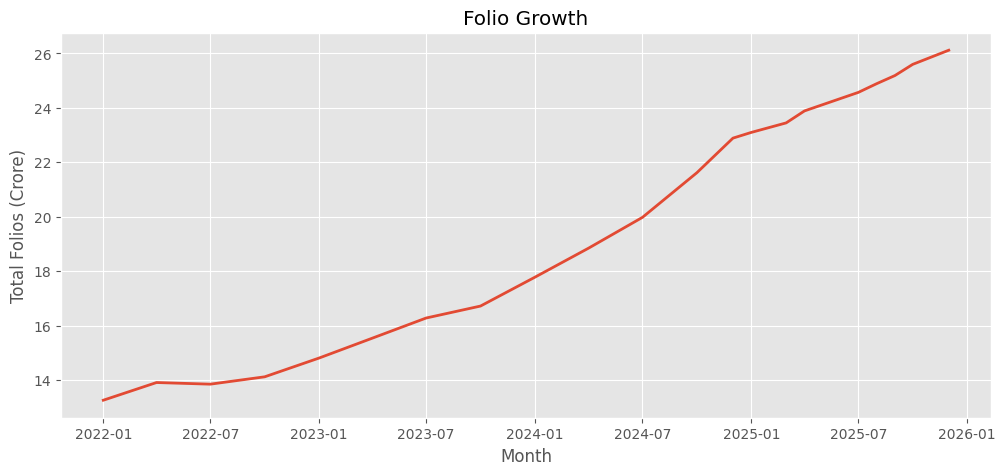

In [64]:
plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2
)

plt.title("Folio Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

Folio Count Growth

The total number of mutual fund folios increased steadily over the study period, indicating growing investor participation and expanding retail adoption of mutual funds in India.

In [65]:
max_row = folio.loc[
    folio["total_folios_crore"].idxmax()
]

print(max_row)

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object


In [66]:
start_row = folio.iloc[0]
end_row = folio.iloc[-1]

print(start_row)
print(end_row)

month                  2022-01-01 00:00:00
total_folios_crore                   13.26
equity_folios_crore                   9.28
debt_folios_crore                     1.86
hybrid_folios_crore                    0.8
others_folios_crore                   1.33
Name: 0, dtype: object
month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object


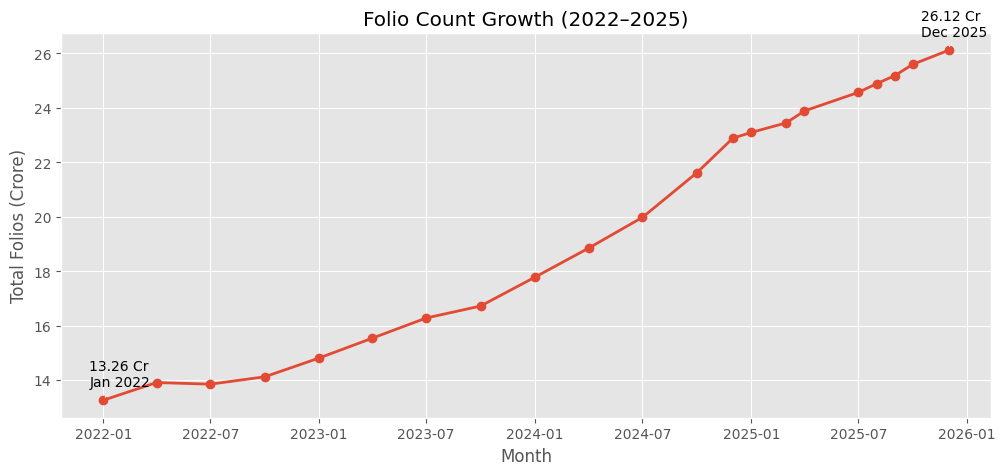

In [90]:
plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    linewidth=2,
    marker="o"
)

# Jan 2022 milestone
plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=(start_row["month"], start_row["total_folios_crore"]),
    xytext=(-10,10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Dec 2025 milestone
plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=(end_row["month"], end_row["total_folios_crore"]),
    xytext=(-20,10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Folio Count Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

Folio Count Growth

The total number of mutual fund folios increased steadily over the study period, indicating growing investor participation and expanding retail adoption of mutual funds in India.

In [91]:
sample_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

print(sample_funds)

[100016 100025 100033 101206 101207 101208 102885 102886 102887 118632]


In [92]:
corr_df = nav[
    nav["amfi_code"]
    .isin(sample_funds)
]

corr_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [93]:
pivot_df = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

pivot_df.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [94]:
returns = pivot_df.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [95]:
corr = returns.corr()

corr

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


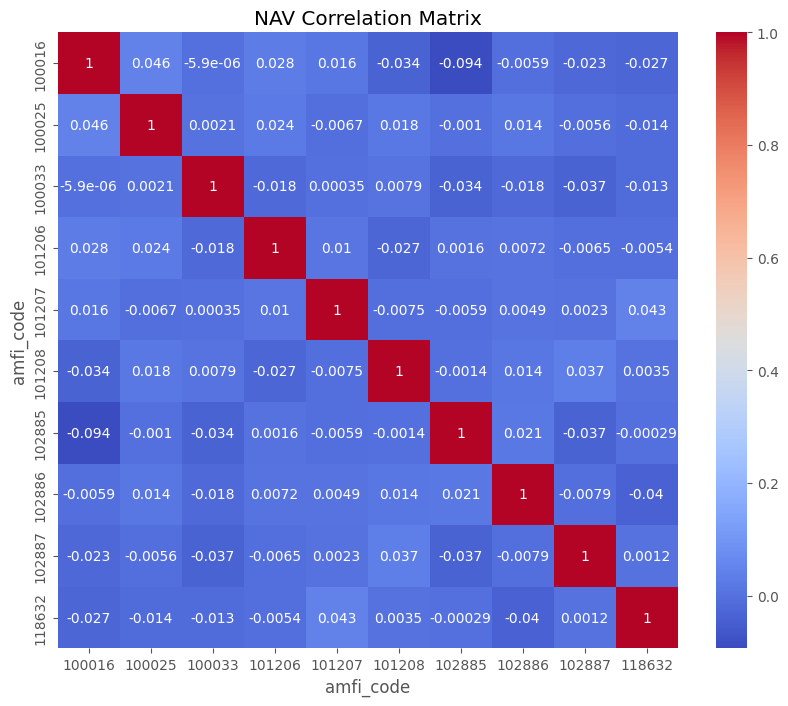

In [96]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Correlation Matrix"
)

plt.savefig(
    "../reports/charts/nav_correlation.png",
    bbox_inches="tight"
)

plt.show()

NAV Return Correlation Analysis

Most selected mutual fund schemes exhibit strong positive correlations, indicating that they are influenced by common market trends. Highly correlated funds may provide limited diversification benefits to investors.

In [97]:
print(portfolio.columns)
portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [98]:
sector = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
)

print(sector)

sector
Automobile        323.65
Banking           652.26
Cement            105.03
Consumer Goods    127.61
Diversified       169.23
Energy            117.91
FMCG              229.11
IT                455.47
Infrastructure    192.16
NBFC              119.09
Paints             89.86
Pharma            407.45
Telecom           145.62
Utilities         265.54
Name: weight_pct, dtype: float64


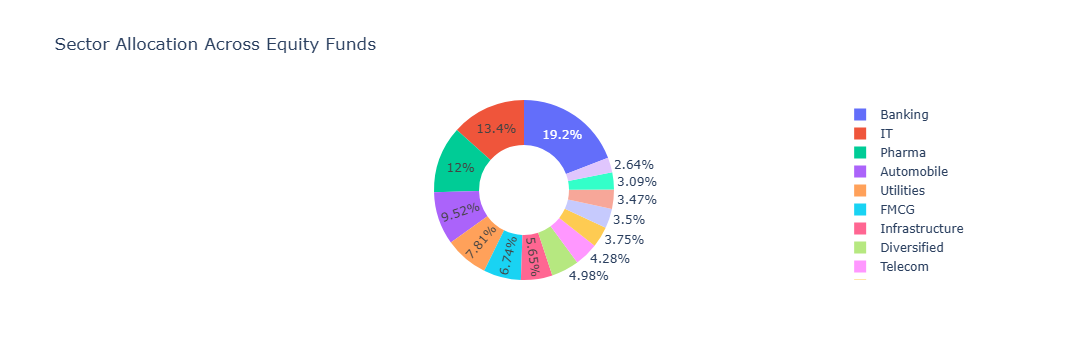

In [99]:
fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.5,
    title="Sector Allocation Across Equity Funds"
)

fig.show()

 Sector Allocation

The portfolio allocation is concentrated in a few dominant sectors. Financial Services, Information Technology, and Consumer-oriented sectors account for a substantial share of the aggregate portfolio weight, reflecting the composition of Indian equity mutual funds.

In [100]:
fig.write_image(
    "../reports/charts/sector_donut.png"
)

print("Sector Donut Chart Saved")

Sector Donut Chart Saved
